# Principal Component Analysis of wine chemical properties


## Part 1

## Research question
How can Principal Component Analysis(PCA) be used to reduce the dimensionality of the wine dataset, while preserving the most important information about the chemiacal properties of wine?

## Explanation and relation to the project
The wine dataset contains several chemical attributes such as alcohol content, magnesium, flavonoids, phenols, color intensity and proline. Since working with many variables at the same time can make analysis complex and difficult to visualize, PCA is used to reduce the number of components while retaining most of the important information in the dataset.
This project is useful because PCA helps identify the combinations of variables that contribute the most to the variation in the wine data. By transforming the original variables into principal components, the project simplifies the dataset, improves visualization and helps in understanding underlying structure of the data. The analysis also helps determine how many components are needed to represent most of the dataset's variance effectively.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("devahuja2808/wine-dataset-for-pca")

print("Path to dataset files:", path)

100%|██████████| 4.42k/4.42k [00:00<00:00, 7.24MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/devahuja2808/wine-dataset-for-pca/versions/1


In [4]:
wine = pd.read_csv(path + "/Wine.csv")

In [5]:
wine.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [6]:
wine.columns

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline',
       'Customer_Segment'],
      dtype='object')

The dataset contains several chemical properties of wine. These variables are appropriate for PCA since the technique is designed to analyze the relationships and patterns among multiple continuous variables.\
**Alcohol** - Measures the alcohol content in the wine. Alcohol level strongly influences the tastes and quality of wine.\
**Malic_Acid** - Represents the amount of malic acid present in the wine, which affects sourness and flavor balance.\
**Ash** - Refers to the mineral content remaining after the wine is burned. It provides information about the composition of wine.\
**Ash_Alcanity** - Measures the alkalinity of ash and helps describe mineral characteristics in the wine.\
**Magnesium** - Indicates the magnesium concentration, which is an important mineral affecting wine chemistry.\
**Total_Phenols** - Represents the total amount of phenolic compounds, which contribute to taste, bitterness and antioxidant properties.\
**Flavanoids** - A subgroup of phenols that strongly influence wine color and flavor.\
**Nonflavanoid_Phenols** - Measures phenolic compounds that are not flavanoids and contribute to wine charcteristics.\
**Proanthocyanins** - Compounds related to tannins that affect bitterness and texture.\
**Color_Intensity** - Measures the depth and richness of the wine's color.\
**Hue** - Describes shade or tone of the wine color.\
**OD280** - Represents the dilution ratio of wine and is related to protein and phenolic content.\
**Proline** - An amino acid found in wine that is often associated with wine quality and aging.

In [7]:
wine = wine.drop(columns = ['Customer_Segment'], axis = 1)

In [8]:
wine.shape

(178, 13)

In [9]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [10]:
scaler = StandardScaler(with_mean=True, with_std=True)
wine_scaled = scaler.fit_transform(wine)

In [11]:
pca_wine = PCA()

In [12]:
pca_wine.fit(wine_scaled)

PCA()

In [13]:
pca_wine.mean_

array([-8.38280756e-16, -1.19754394e-16, -8.37033314e-16, -3.99181312e-17,
       -3.99181312e-17,  0.00000000e+00, -3.99181312e-16,  3.59263181e-16,
       -1.19754394e-16,  2.49488320e-17,  1.99590656e-16,  3.19345050e-16,
       -1.59672525e-16])

In [14]:
scores = pca_wine.transform(wine_scaled)

In [15]:
pca_wine.components_

array([[ 0.1443294 , -0.24518758, -0.00205106, -0.23932041,  0.14199204,
         0.39466085,  0.4229343 , -0.2985331 ,  0.31342949, -0.0886167 ,
         0.29671456,  0.37616741,  0.28675223],
       [ 0.48365155,  0.22493093,  0.31606881, -0.0105905 ,  0.299634  ,
         0.06503951, -0.00335981,  0.02877949,  0.03930172,  0.52999567,
        -0.27923515, -0.16449619,  0.36490283],
       [-0.20738262,  0.08901289,  0.6262239 ,  0.61208035,  0.13075693,
         0.14617896,  0.1506819 ,  0.17036816,  0.14945431, -0.13730621,
         0.08522192,  0.16600459, -0.12674592],
       [-0.0178563 ,  0.53689028, -0.21417556,  0.06085941, -0.35179658,
         0.19806835,  0.15229479, -0.20330102,  0.39905653,  0.06592568,
        -0.42777141,  0.18412074, -0.23207086],
       [-0.26566365,  0.03521363, -0.14302547,  0.06610294,  0.72704851,
        -0.14931841, -0.10902584, -0.50070298,  0.13685982, -0.07643678,
        -0.17361452, -0.10116099, -0.1578688 ],
       [ 0.21353865,  0.536813

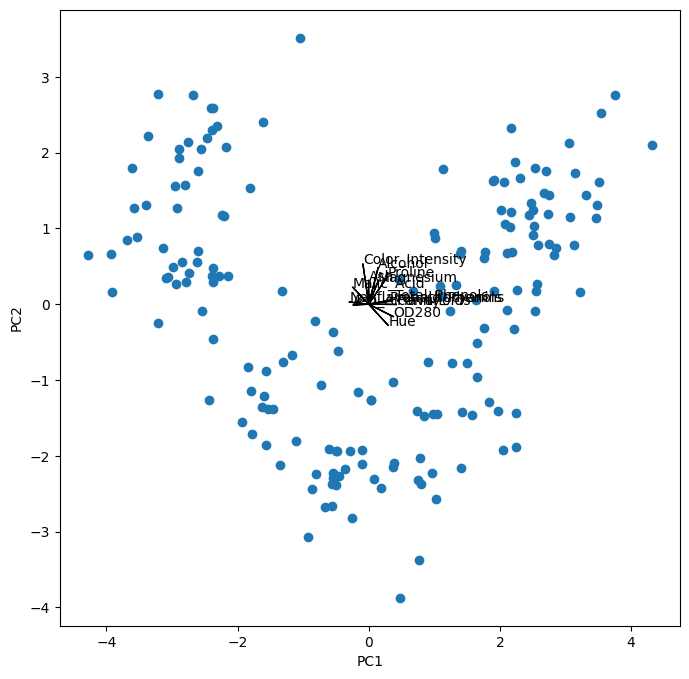

In [16]:
i, j = 0, 1
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pca_wine.components_.shape[1]):
    ax.arrow(0, 0, pca_wine.components_[i,k], pca_wine.components_[j,k])
    ax.text(pca_wine.components_[i,k],
            pca_wine.components_[j,k],
            wine.columns[k])

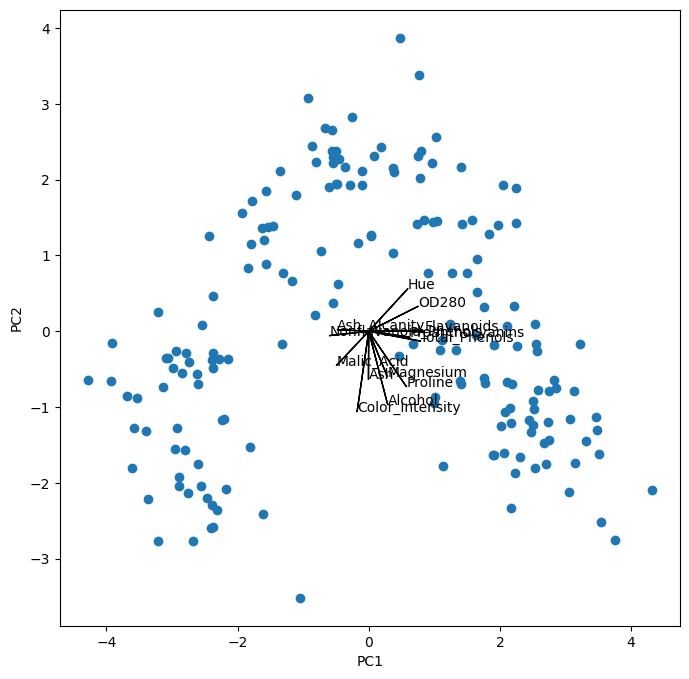

In [17]:
scale_arrow = s_ = 2
scores[:,1] *= -1
pca_wine.components_[1] *= -1 # flip the y-axis
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pca_wine.components_.shape[1]):
    ax.arrow(0, 0, s_*pca_wine.components_[i,k], s_*pca_wine.components_[j,k])
    ax.text(s_*pca_wine.components_[i,k],
            s_*pca_wine.components_[j,k],
            wine.columns[k])


The PCA biplot shows that the wine dataset contains meaningful structure and relationships among chemical variables. Several predictors such as Alcohol, Flavanoids, Total_Phenols and Proline strongly influence the first principal component, while color related vaiables contribute more to the second component. The clustering of observations suggests that wine with similar chemical compositions group together in reduced PCA space.

The biplot shows both the wine observations and the contribution of the chemical variables to the principal components. The observations from visible clusters, indicating that wines with similar chemical properties are grouped together. Variables such as Alcohol, Flavanoids, Total_Phenols and Proline have strong loading vectors, meaning they contribute greatly to the variation in the dataset and are positively correlated. Color_Intensity and Hue also influence the seperation of observations along PC2. The direction and length of the loading vectors show the relationship and strength of each variable in the PCA space.

In [18]:
%%capture
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ticks = np.arange(pca_wine.n_components_)+1
ax = axes[0]
ax.plot(ticks,
        pca_wine.explained_variance_ratio_,
        marker='o')
ax.set_xlabel('Principal Component');
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0,1])
ax.set_xticks(ticks)

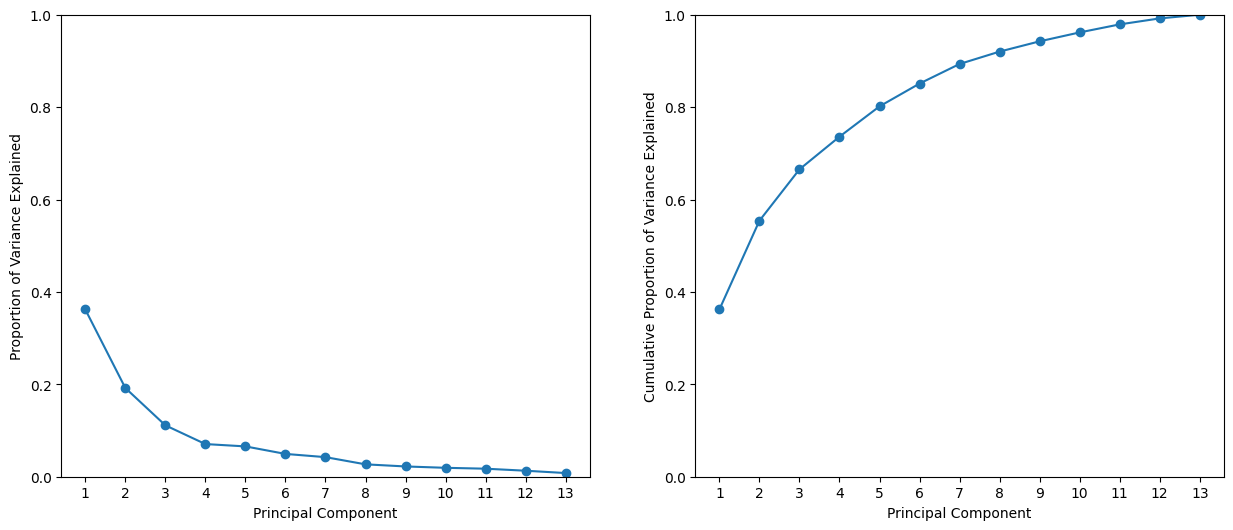

In [19]:
ax = axes[1]
ax.plot(ticks,
        pca_wine.explained_variance_ratio_.cumsum(),
        marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
fig

The scree plot shows that the first principal component explains the largest amount of variance in the wine dataset, followed by a gradual decrease in variance explained by the remaining components. The first two principal components together explain about 55% of the total variance, which provides a moderate representation of the dataset for visualization in the biplot. This is useful for identifying general patterns and relationships among observations and variables. However, since a considerable amount of variation still remains unexplained, the first two components may not fully capture the complete structure of the dataset. Based on the cumulative variance plot, using around 5 principal components would be more appropriate because they explain approximately 80% of the total variance while still reducing the dimensionality of the data effectively.

## Part 2 : Principal components with missing values

In [22]:
X = wine_scaled
n_omit = 20
np.random.seed(15)
r_idx = np.random.choice(np.arange(X.shape[0]),
                         n_omit,
                         replace=False)
c_idx = np.random.choice(np.arange(X.shape[1]),
                         n_omit,
                         replace=True)
Xna = X.copy()
Xna[r_idx, c_idx] = np.nan

In [23]:
def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X, full_matrices=False)
    L = U[:,:M] * D[None,:M]
    return L.dot(V[:M])


In [24]:
Xhat = Xna.copy()
Xbar = np.nanmean(Xhat, axis=0)
Xhat[r_idx, c_idx] = Xbar[c_idx]

In [25]:
thresh = 1e-7
rel_err = 1
count = 0
ismiss = np.isnan(Xna)
mssold = np.mean(Xhat[~ismiss]**2)
mss0 = np.mean(Xna[~ismiss]**2)

In [26]:
while rel_err > thresh:
    count += 1
    # Step 2(a)
    Xapp = low_rank(Xhat, M=1)
    # Step 2(b)
    Xhat[ismiss] = Xapp[ismiss]
    # Step 2(c)
    mss = np.mean(((Xna - Xapp)[~ismiss])**2)
    rel_err = (mssold - mss) / mss0
    mssold = mss
    print("Iteration: {0}, MSS:{1:.3f}, Rel.Err {2:.2e}"
          .format(count, mss, rel_err))

Iteration: 1, MSS:0.639, Rel.Err 3.61e-01
Iteration: 2, MSS:0.639, Rel.Err 3.62e-04
Iteration: 3, MSS:0.639, Rel.Err 9.21e-06
Iteration: 4, MSS:0.639, Rel.Err 2.83e-07
Iteration: 5, MSS:0.639, Rel.Err 9.50e-09


In this part, missing values were manually created in the standardized wine dataset to test how well the imputation method could recover the original values. A total of 20 values were randomly removed from the dataset by selecting random row and column positions and replacing those values with NaN. Since the wine dataset has 178 observations and 13 variables, this represents about 0.86% of the total data values. This percentage is small enough to avoid heavily damaging the dataset but still allows comparison between the true values and the imputed values.

A realistic scenario for this project is that some chemical measurements may be missing during wine testing because of lab equipment errors, recording mistakes or incomplete sample testing. To handle this, the missing values were first replaced with column mean values and then iterative low-rank approximation method was applied using SVD. This method estimates missing values based on the main patterns in the dataset. The iteration continues until the relative error becomes very small, showing that the imputed values have stabilized.

In [31]:
M = [1,2,3,4,5,6,7]
for i in M:
  Xhat = Xna.copy()
  Xbar = np.nanmean(Xhat, axis=0)
  Xhat[r_idx, c_idx] = Xbar[c_idx]

  thresh = 1e-7
  rel_err = 1
  count = 0
  ismiss = np.isnan(Xna)
  mssold = np.mean(Xhat[~ismiss]**2)
  mss0 = np.mean(Xna[~ismiss]**2)

  while rel_err > thresh:
    count += 1
    # Step 2(a)
    Xapp = low_rank(Xhat, M=i)
    # Step 2(b)
    Xhat[ismiss] = Xapp[ismiss]
    # Step 2(c)
    mss = np.mean(((Xna - Xapp)[~ismiss])**2)
    rel_err = (mssold - mss) / mss0
    mssold = mss

  print("M: {0}, Iteration: {1}, MSS:{2:.3f}, Rel.Err {3:.2e}".format(i, count, mss, rel_err))

M: 1, Iteration: 5, MSS:0.639, Rel.Err 9.50e-09
M: 2, Iteration: 6, MSS:0.446, Rel.Err 1.18e-08
M: 3, Iteration: 8, MSS:0.334, Rel.Err 2.82e-08
M: 4, Iteration: 8, MSS:0.264, Rel.Err 9.12e-08
M: 5, Iteration: 20, MSS:0.198, Rel.Err 6.76e-08
M: 6, Iteration: 19, MSS:0.148, Rel.Err 8.72e-08
M: 7, Iteration: 36, MSS:0.106, Rel.Err 8.95e-08


The result show that as the number of principal components increases from M=1 to M=7, the MSS decreases from 0.639 to 0.106. This means the imputation becomes more accurate because more principal components capture more variation from the wine dataset. However, higher M values also require more iterations to coverage.

In [32]:
for i in M:
  Xhat = Xna.copy()
  Xbar = np.nanmean(Xhat, axis=0)
  Xhat[r_idx, c_idx] = Xbar[c_idx]

  thresh = 1e-7
  rel_err = 1
  count = 0
  ismiss = np.isnan(Xna)
  mssold = np.mean(Xhat[~ismiss]**2)
  mss0 = np.mean(Xna[~ismiss]**2)

  while rel_err > thresh:
    count += 1
    # Step 2(a)
    Xapp = low_rank(Xhat, M=i)
    # Step 2(b)
    Xhat[ismiss] = Xapp[ismiss]
    # Step 2(c)
    mss = np.mean(((Xna - Xapp)[~ismiss])**2)
    rel_err = (mssold - mss) / mss0
    mssold = mss

  cor = np.corrcoef(Xapp[ismiss], X[ismiss])[0,1]
  print("M: {0}, Correlation between True and Imputed values: {1}".format(i, cor))

M: 1, Correlation between True and Imputed values: 0.5921393839540464
M: 2, Correlation between True and Imputed values: 0.6362224652678393
M: 3, Correlation between True and Imputed values: 0.6226001767971154
M: 4, Correlation between True and Imputed values: 0.7108346960170508
M: 5, Correlation between True and Imputed values: 0.6564916672592158
M: 6, Correlation between True and Imputed values: 0.6374887673086906
M: 7, Correlation between True and Imputed values: 0.6349514493256609


The results show that the correlation generally improves as more principal components are included, although the improvement is not perfectly consistent for every value of M. The highest correlation was obtained wwhen M=4, with a correlaton value of approximately 0.71. This suggests that using four principal components provides the best balance between capturing important variation in the wine datasetand avaiding unnecessary complexity or noise.

When fewer principal components were used, such as M=1 or M=2, the correlations were lower because the model could not capture enough information from the dataset. On the other hand, increasing M beyond 4 did not improve performance and slightly reduced the correlation values, possibly because additional components began capturing noise rather than meaningful structure. Overall, the imputed values appear reasonably reliable in the context of this wine dataset, since PCA was able to preserve the underlying relationships among the chemical variables while estimating the missing values.